# LAPOP Respondent-Level Event-Time Playground

Use this notebook to experiment with the respondent-level LAPOP BVR exposure design without changing the production script. The controls below let you change sample restrictions, cohort definitions, fixed-effect regressions, and event-study plots, then immediately see how the coefficients move.

The production run lives in `src/analysis/run_lapop_individual_event_time.py`. This notebook intentionally recomputes the design from the cleaned LAPOP file and the project treatment-timing file so you can inspect how data-management choices affect the graph.

In [1]:
from __future__ import annotations

from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

LAPOP_PATH = ROOT / "data" / "clean" / "lapop" / "lapop_brazil_with_pca_indices_regression_ready_corrected.parquet"
TREATMENT_PATH = ROOT / "data" / "clean" / "tse_bvr" / "municipality_bvr_first_treat.parquet"

OUTCOMES = {
    "trust_index_std": "Trust in institutions",
    "democracy_index_std": "Trust in democracy",
}
COLORS = {
    "trust_index_std": "#294C60",
    "democracy_index_std": "#7A4E2D",
}

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 140, "savefig.dpi": 300})

print(f"Project root: {ROOT}")
print(f"LAPOP file exists: {LAPOP_PATH.exists()}  -> {LAPOP_PATH.relative_to(ROOT)}")
print(f"Treatment file exists: {TREATMENT_PATH.exists()}  -> {TREATMENT_PATH.relative_to(ROOT)}")

Project root: /Users/gabrielsgaspar/Projects/bioimetric-voting
LAPOP file exists: True  -> data/clean/lapop/lapop_brazil_with_pca_indices_regression_ready_corrected.parquet
Treatment file exists: True  -> data/clean/tse_bvr/municipality_bvr_first_treat.parquet


## 1. Choose Data-Management Settings

Edit this cell and rerun the notebook below. The default values mirror the production respondent-level module as closely as possible. The scenario tools later in the notebook make it easy to compare alternatives.

In [27]:
CONFIG = {
    # Survey years. The cleaned file uses `year` as the benchmark analysis year.
    "min_year": 2005,
    "max_year": 2020,

    # Sample restrictions.
    "require_all_wave_municipalities": True,
    "drop_under_18": True,
    "min_age": 18,
    "exclude_hybrid": False,
    "include_never_treated": True,
    "drop_mixed_cohort": False,

    # Event-time construction.
    "event_min": -8,
    "event_max": 8,
    "event_step": 2,
    "reference_event_time": -2,

    # Regression controls. These are the individual controls used in the trust barplots,
    # with an age cubic added for respondent-level timing specifications.
    "controls": ["low_ed", "female", "white", "married", "working", "age"],
    "municipality_controls": ["female", "white", "married", "working", "age"],

    # Model options.
    "cluster": "muni_year",
    "use_weights": False,
    "weight_col": "wt",
}

CONFIG

{'min_year': 2005,
 'max_year': 2020,
 'require_all_wave_municipalities': True,
 'drop_under_18': True,
 'min_age': 18,
 'exclude_hybrid': False,
 'include_never_treated': True,
 'drop_mixed_cohort': False,
 'event_min': -8,
 'event_max': 8,
 'event_step': 2,
 'reference_event_time': -2,
 'controls': ['low_ed', 'female', 'white', 'married', 'working', 'age'],
 'municipality_controls': ['female', 'white', 'married', 'working', 'age'],
 'cluster': 'muni_year',
 'use_weights': False,
 'weight_col': 'wt'}

## 2. Build Respondent-Level Timing Variables

This section rebuilds `first_eligible_year`, `event_time`, `T_im`, and `registered_under_bvr` from the cleaned LAPOP file plus the BVR treatment-timing file. Never-treated municipalities get missing `event_time`; in the event-study regressions below they are kept as controls by setting all event-time dummies to zero.

In [28]:
df = load_lapop_base()


In [56]:

def fit_fe(df: pd.DataFrame, outcome: str, rhs_terms: list[str], config: dict = CONFIG):
    model_df = complete_case(df, outcome, rhs_terms, config)
    rhs = " + ".join(rhs_terms + ["C(municipality_id)", "C(year)"])
    formula = f"{outcome} ~ {rhs}"
    if config["use_weights"] and config["weight_col"] in model_df.columns:
        model = smf.wls(formula, data=model_df, weights=model_df[config["weight_col"]])
    else:
        model = smf.ols(formula, data=model_df)
    result = model.fit(cov_type="cluster", cov_kwds={"groups": model_df[config["cluster"]]})
    result.model_df = model_df
    result.formula_text = formula
    return result

In [54]:
formula = "trust_index_std ~ treatment_dummy + C(year) + C(municipality_id)"
model_df = df.dropna(subset=["age", "treatment_dummy", "trust_index_std", "municipality_name"])
model = smf.ols(formula, data=model_df)
result = model.fit(cov_type="cluster", cov_kwds={"groups": model_df["municipality_name"]})

KeyboardInterrupt: 

In [ ]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        trust_index_std   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     104.5
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:20:41   Log-Likelihood:                -21309.
No. Observations:               15472   AIC:                         4.269e+04
Df Residuals:                   15436   BIC:                         4.297e+04
Df Model:                          35                                         
Covariance Type:              cluster                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.3269      0.054      6.028      0.000       0.221       0.433
C(year)[T.2008]    -0.0165      0.057     -0.291      0.771      -0.128       0.095
C(year)[T.2010]     0.2128      0.067      3.177      0.001       0.082       0.344
C(year)[T.2012]     0.0127      0.073      0.174      0.861      -0.130       0.155
C(year)[T.2014]    -0.4258      0.064     -6.667      0.000      -0.551      -0.301
C(year)[T.2016]    -0.6695      0.064    -10.420      0.000      -0.795      -0.544
C(year)[T.2018]    -0.1415      0.059     -2.403      0.016      -0.257      -0.026
C(year)[T.2020]    -0.1342      0.058     -2.312      0.021      -0.248      -0.020
C(year)[T.2022]     0.0743      0.055      1.344      0.179      -0.034       0.183
C(state)[T.AL]     -0.1064      0.081     -1.308      0.191      -0.266       0.053
C(state)[T.AM]      0.0956      0.121      0.790      0.430      -0.142       0.333
C(state)[T.AP]     -0.0728      0.044     -1.673      0.094      -0.158       0.012
C(state)[T.BA]     -0.2320      0.121     -1.912      0.056      -0.470       0.006
C(state)[T.CE]     -0.1063      0.044     -2.388      0.017      -0.193      -0.019
C(state)[T.DF]     -0.6221      0.015    -40.222      0.000      -0.652      -0.592
C(state)[T.ES]     -0.2479      0.062     -4.010      0.000      -0.369      -0.127
C(state)[T.GO]     -0.2552      0.081     -3.141      0.002      -0.414      -0.096
C(state)[T.MA]     -0.1034      0.125     -0.828      0.407      -0.348       0.141
C(state)[T.MG]     -0.1705      0.069     -2.480      0.013      -0.305      -0.036
C(state)[T.MS]      0.0468      0.112      0.418      0.676      -0.173       0.266
C(state)[T.MT]     -0.1217      0.102     -1.197      0.231      -0.321       0.078
C(state)[T.PA]     -0.1254      0.121     -1.037      0.300      -0.362       0.112
C(state)[T.PB]     -0.2036      0.092     -2.214      0.027      -0.384      -0.023
C(state)[T.PE]     -0.0594      0.077     -0.768      0.442      -0.211       0.092
C(state)[T.PI]     -0.2850      0.077     -3.683      0.000      -0.437      -0.133
C(state)[T.PR]     -0.2065      0.040     -5.195      0.000      -0.284      -0.129
C(state)[T.RJ]     -0.3656      0.049     -7.516      0.000      -0.461      -0.270
C(state)[T.RN]     -0.2190      0.094     -2.335      0.020      -0.403      -0.035
C(state)[T.RO]     -0.1988      0.062     -3.216      0.001      -0.320      -0.078
C(state)[T.RR]     -0.5380      0.060     -8.994      0.000      -0.655      -0.421
C(state)[T.RS]     -0.1167      0.067     -1.742      0.082      -0.248       0.015
C(state)[T.SC]     -0.1814      0.052     -3.471      0.001      -0.284      -0.079
C(state)[T.SE]     -0.3226      0.107     -3.018      0.003      -0.532      -0.113
C(state)[T.SP]     -0.3148      0.042     -7.578      0.000

In [37]:
df[["municipality_name", "age", "treatment_dummy", "trust_index_std"]]

,municipality_name,age,treatment_dummy,trust_index_std
0,manaus,35.0,0,-1.123757
1,manaus,40.0,0,0.077265
2,manaus,32.0,0,-1.726188
3,manaus,24.0,0,-0.143232
4,manaus,60.0,0,1.076295
...,...,...,...,...
15488,pacuja,24.0,0,1.152992
15489,fortaleza,69.0,0,2.585697
15490,pacuja,29.0,0,-0.551632
15491,maracanau,28.0,1,-0.219020


In [ ]:
def event_col(k: int) -> str:
    return f"event_m{abs(k)}" if k < 0 else f"event_p{k}"


def event_grid(config: dict) -> list[int]:
    return list(range(config["event_min"], config["event_max"] + config["event_step"], config["event_step"]))


def bin_event_time(value: float, config: dict) -> float:
    if pd.isna(value):
        return np.nan
    if value <= config["event_min"]:
        return float(config["event_min"])
    if value >= config["event_max"]:
        return float(config["event_max"])
    return float(config["event_step"] * np.floor(value / config["event_step"]))


def load_lapop_base() -> pd.DataFrame:
    df = pd.read_parquet(LAPOP_PATH).copy()
    treatment = pd.read_parquet(TREATMENT_PATH)[["municipality_id", "year_first_treat"]].copy()
    treatment["municipality_id"] = treatment["municipality_id"].astype("string")
    treatment = treatment.rename(columns={"year_first_treat": "year_first_treat_project"})

    df["municipality_id"] = df["municipality_id"].astype("string")
    df = df.merge(treatment, on="municipality_id", how="left", validate="many_to_one")
    df["year_first_treat"] = pd.to_numeric(df["year_first_treat_project"], errors="coerce").fillna(9999).astype(int)
    df = df.drop(columns=["year_first_treat_project"])

    numeric_cols = [
        "year", "survey_year", "age", "year_first_treat", "is_hybrid", "low_ed", "female",
        "white", "married", "working", "trust_index_std", "democracy_index_std", "wt",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def balanced_municipalities(df: pd.DataFrame, config: dict) -> tuple[set[str], list[int]]:
    window = df[(df["year"] >= config["min_year"]) & (df["year"] <= config["max_year"]) & df["municipality_id"].notna()].copy()
    wave_years = sorted(int(y) for y in window["year"].dropna().unique())
    counts = window.groupby("municipality_id")["year"].nunique()
    keep = set(counts[counts == len(wave_years)].index.astype(str))
    return keep, wave_years


def prepare_event_data(config: dict = CONFIG) -> pd.DataFrame:
    df = load_lapop_base()
    keep_munis, wave_years = balanced_municipalities(df, config)

    df = df[(df["year"] >= config["min_year"]) & (df["year"] <= config["max_year"])].copy()
    df["balanced_municipality_all_waves"] = df["municipality_id"].astype(str).isin(keep_munis).astype(int)
    df["analysis_wave_years"] = ",".join(str(y) for y in wave_years)

    if config["require_all_wave_municipalities"]:
        df = df[df["balanced_municipality_all_waves"] == 1].copy()
    if config["drop_under_18"]:
        df = df[df["age"].ge(config["min_age"])].copy()
    if config["exclude_hybrid"]:
        df = df[pd.to_numeric(df["is_hybrid"], errors="coerce").fillna(0).eq(0)].copy()
    if not config["include_never_treated"]:
        df = df[df["year_first_treat"].lt(9999)].copy()

    age_floor = np.floor(df["age"])
    df["interview_year_for_event_time"] = df["year"]
    df["first_eligible_year"] = df["interview_year_for_event_time"] - age_floor + 18

    treated_by_interview = df["year_first_treat"].lt(9999) & df["year_first_treat"].le(df["interview_year_for_event_time"])
    df["treatment_dummy"] = treated_by_interview.astype(int)
    first_entry_under_bvr = treated_by_interview & df["first_eligible_year"].ge(df["year_first_treat"])
    mixed = treated_by_interview & df["first_eligible_year"].lt(df["year_first_treat"])

    df["registered_under_bvr"] = first_entry_under_bvr.astype(int)
    df["mixed_cohort"] = mixed.astype(int)
    df["T_im"] = np.select([first_entry_under_bvr, mixed], [1, -1], default=0).astype(int)

    finite_treat = df["year_first_treat"].lt(9999)
    exposure_start = np.maximum(df["year_first_treat"], df["first_eligible_year"])
    df["event_time"] = df["interview_year_for_event_time"] - exposure_start
    df.loc[~finite_treat | df["event_time"].isna(), "event_time"] = np.nan
    df["event_time_bin"] = df["event_time"].apply(lambda value: bin_event_time(value, config))

    for k in event_grid(config):
        if k == config["reference_event_time"]:
            continue
        df[event_col(k)] = (df["event_time_bin"] == k).astype(int)

    df["muni_year"] = df["municipality_id"].astype("string").fillna("missing") + "_" + df["year"].astype("Int64").astype("string").fillna("missing")
    df["no_hybrid_sample"] = pd.to_numeric(df["is_hybrid"], errors="coerce").fillna(0).eq(0).astype(int)

    if config["drop_mixed_cohort"]:
        df = df[df["mixed_cohort"] == 0].copy()
    return df


df = prepare_event_data(CONFIG)
df.shape

(2817, 84)

In [4]:
def sample_summary(df: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "rows": len(df),
        "municipalities": df["municipality_id"].nunique(),
        "municipality_year_cells": df[["municipality_id", "year"]].drop_duplicates().shape[0],
        "waves": df["year"].nunique(),
        "min_year": df["year"].min(),
        "max_year": df["year"].max(),
        "under_18_rows": int(df["age"].lt(18).sum()),
        "hybrid_rows": int(pd.to_numeric(df["is_hybrid"], errors="coerce").fillna(0).ne(0).sum()),
        "always_bvr_rows": int(df["registered_under_bvr"].eq(1).sum()),
        "low_ed_always_bvr_rows": int((df["registered_under_bvr"].eq(1) & df["low_ed"].eq(1)).sum()),
        "mixed_rows": int(df["mixed_cohort"].eq(1).sum()),
        "never_or_pre_bvr_rows": int(df["T_im"].eq(0).sum()),
    })


display(sample_summary(df).to_frame("value"))
display(df["event_time_bin"].value_counts(dropna=False).sort_index().rename("rows").to_frame())
display(df.groupby(["municipality_id", "municipality_name", "state"], dropna=False).size().rename("rows").reset_index().sort_values("rows", ascending=False).head(20))

,value
rows,2817
municipalities,8
municipality_year_cells,64
waves,8
min_year,2006
max_year,2020
under_18_rows,0
hybrid_rows,0
always_bvr_rows,40
low_ed_always_bvr_rows,3


,rows
event_time_bin,
-8.0,194
-6.0,56
-4.0,175
-2.0,135
0.0,98
2.0,96
4.0,57
6.0,68
8.0,39


,municipality_id,municipality_name,state,rows
5,3550308,sao paulo,SP,834
3,3304557,rio de janeiro,RJ,437
7,5300108,brasilia,DF,361
0,1501402,belem,PA,315
1,2304400,fortaleza,CE,304
6,5208707,goiania,GO,242
2,3106200,belo horizonte,MG,220
4,3549904,sao jose dos campos,SP,104


## 3. Regression Helpers

The helpers below estimate the same basic specifications as the production table using Python `statsmodels` formulas:

- municipality-level assignment: `treatment_dummy * low_ed + controls + municipality FE + year FE`
- individual ITT: `registered_under_bvr + mixed_cohort + controls + municipality FE + year FE`
- triple difference: `registered_under_bvr * low_ed + mixed_cohort * low_ed + controls + municipality FE + year FE`
- event study: event-time dummies plus controls, municipality FE, and year FE

Standard errors are clustered by municipality-year by default.

In [5]:
def formula_vars(rhs_terms: list[str]) -> list[str]:
    vars_found = []
    for term in rhs_terms:
        cleaned = term.replace("*", "+").replace(":", "+").replace("C(", "").replace(")", "")
        for piece in cleaned.split("+"):
            name = piece.strip()
            if name and re.match(r"^[A-Za-z_]\w*$", name):
                vars_found.append(name)
    return sorted(set(vars_found))


def complete_case(df: pd.DataFrame, outcome: str, rhs_terms: list[str], config: dict = CONFIG) -> pd.DataFrame:
    required = [outcome, "municipality_id", "year", config["cluster"]] + formula_vars(rhs_terms)
    if config["use_weights"] and config["weight_col"] in df.columns:
        required.append(config["weight_col"])
    required = [col for col in dict.fromkeys(required) if col in df.columns]
    return df.dropna(subset=required).copy()


def fit_fe(df: pd.DataFrame, outcome: str, rhs_terms: list[str], config: dict = CONFIG):
    model_df = complete_case(df, outcome, rhs_terms, config)
    rhs = " + ".join(rhs_terms + ["C(municipality_id)", "C(year)"])
    formula = f"{outcome} ~ {rhs}"
    if config["use_weights"] and config["weight_col"] in model_df.columns:
        model = smf.wls(formula, data=model_df, weights=model_df[config["weight_col"]])
    else:
        model = smf.ols(formula, data=model_df)
    result = model.fit(cov_type="cluster", cov_kwds={"groups": model_df[config["cluster"]]})
    result.model_df = model_df
    result.formula_text = formula
    return result


def tidy_terms(result, terms: list[str], outcome: str, spec: str) -> pd.DataFrame:
    rows = []
    for term in terms:
        if term not in result.params.index:
            rows.append({"outcome": outcome, "spec": spec, "term": term, "estimate": np.nan, "std_error": np.nan, "p_value": np.nan, "n_obs": int(result.nobs)})
            continue
        rows.append({
            "outcome": outcome,
            "spec": spec,
            "term": term,
            "estimate": result.params[term],
            "std_error": result.bse[term],
            "p_value": result.pvalues[term],
            "n_obs": int(result.nobs),
        })
    return pd.DataFrame(rows)


def run_main_specs(df: pd.DataFrame, outcome: str, config: dict = CONFIG) -> tuple[pd.DataFrame, dict]:
    controls = config["controls"]
    municipal_controls = config["municipality_controls"]
    controls_no_low_ed = [c for c in controls if c != "low_ed"]

    specs = {
        "municipality_level": ["treatment_dummy * low_ed"] + municipal_controls,
        "individual_itt": ["registered_under_bvr", "mixed_cohort"] + controls,
        "individual_triple_diff": ["registered_under_bvr * low_ed", "mixed_cohort * low_ed"] + controls_no_low_ed,
    }
    keep_terms = {
        "municipality_level": ["treatment_dummy", "treatment_dummy:low_ed"],
        "individual_itt": ["registered_under_bvr", "mixed_cohort"],
        "individual_triple_diff": ["registered_under_bvr", "registered_under_bvr:low_ed", "mixed_cohort", "mixed_cohort:low_ed"],
    }

    results = {}
    rows = []
    for spec, rhs_terms in specs.items():
        result = fit_fe(df, outcome, rhs_terms, config)
        results[spec] = result
        rows.append(tidy_terms(result, keep_terms[spec], outcome, spec))
    return pd.concat(rows, ignore_index=True), results


all_main_rows = []
main_models = {}
for outcome in OUTCOMES:
    rows, models = run_main_specs(df, outcome, CONFIG)
    all_main_rows.append(rows)
    main_models[outcome] = models

main_table = pd.concat(all_main_rows, ignore_index=True)
display(main_table.assign(
    estimate=lambda x: x["estimate"].round(3),
    std_error=lambda x: x["std_error"].round(3),
    p_value=lambda x: x["p_value"].round(3),
))

,outcome,spec,term,estimate,std_error,p_value,n_obs
0,trust_index_std,municipality_level,treatment_dummy,0.251,0.106,0.018,2425
1,trust_index_std,municipality_level,treatment_dummy:low_ed,0.041,0.093,0.656,2425
2,trust_index_std,individual_itt,registered_under_bvr,0.235,0.184,0.202,2425
3,trust_index_std,individual_itt,mixed_cohort,0.269,0.108,0.013,2425
4,trust_index_std,individual_triple_diff,registered_under_bvr,0.257,0.194,0.184,2425
5,trust_index_std,individual_triple_diff,registered_under_bvr:low_ed,-0.310,0.219,0.157,2425
6,trust_index_std,individual_triple_diff,mixed_cohort,0.239,0.110,0.029,2425
7,trust_index_std,individual_triple_diff,mixed_cohort:low_ed,0.078,0.103,0.451,2425
8,democracy_index_std,municipality_level,treatment_dummy,0.428,0.146,0.003,2425
9,democracy_index_std,municipality_level,treatment_dummy:low_ed,0.088,0.139,0.526,2425


## 4. Event-Study Plot

Change `OUTCOME_TO_PLOT`, rerun the cell, and inspect how the graph changes after editing `CONFIG` above. The plotted reference period is the omitted event-time bin.

In [7]:
CONFIG["controls"]

['low_ed', 'female', 'white', 'married', 'working', 'age', 'age_sq', 'age_cu']

In [8]:
rhs_terms = event_terms(CONFIG) + ['low_ed', 'female', 'white', 'married', 'working']
rhs_terms

['event_m8',
 'event_m6',
 'event_m4',
 'event_p0',
 'event_p2',
 'event_p4',
 'event_p6',
 'event_p8',
 'low_ed',
 'female',
 'white',
 'married',
 'working']

In [26]:
df.municipality_name.unique()

<StringArray>
['belem', 'fortaleza', 'belo horizonte', 'rio de janeiro', 'sao paulo', 'sao jose dos campos', 'goiania', 'brasilia']
Length: 8, dtype: string

In [ ]:
print("this")

In [24]:
rhs = " + ".join(rhs_terms + ["C(municipality_id)", "C(year)"])
formula = f"{outcome} ~ {rhs}"
model_df = df.dropna(subset=rhs_terms).query("low_ed==0")
model = smf.ols(formula, data=model_df)
result = model.fit(cov_type="cluster", cov_kwds={"groups": model_df[CONFIG["cluster"]]})

In [25]:
result.summary()

/Users/gabrielsgaspar/.pyenv/versions/3.11.9/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 26
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     democracy_index_std   R-squared:                       0.110
Model:                             OLS   Adj. R-squared:                  0.095
Method:                  Least Squares   F-statistic:                     12.40
Date:                 Fri, 24 Apr 2026   Prob (F-statistic):           3.77e-16
Time:                         14:05:28   Log-Likelihood:                -2210.3
No. Observations:                 1628   AIC:                             4475.
Df Residuals:                     1601   BIC:                             4620.
Df Model:                           26                                         
Covariance Type:               cluster                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -0.0969      0.172     -0.564      0.573      -0.434       0.240
C(municipality_id)[T.2304400]     0.1772      0.209      0.850      0.395      -0.232       0.586
C(municipality_id)[T.3106200]    -0.0078      0.172     -0.045      0.964      -0.344       0.329
C(municipality_id)[T.3304557]    -0.0961      0.170     -0.567      0.571      -0.428       0.236
C(municipality_id)[T.3549904]     0.0878      0.222      0.395      0.693      -0.348       0.523
C(municipality_id)[T.3550308]     0.0523      0.165      0.318      0.751      -0.270       0.375
C(municipality_id)[T.5208707]    -0.3483      0.177     -1.965      0.049      -0.696      -0.001
C(municipality_id)[T.5300108]    -0.3566      0.173     -2.064      0.039      -0.695      -0.018
C(year)[T.2008]                   0.3197      0.102      3.146      0.002       0.121       0.519
C(year)[T.2010]                   0.5056      0.085      5.963      0.000       0.339       0.672
C(year)[T.2012]                   0.1204      0.072      1.676      0.094      -0.020       0.261
C(year)[T.2014]                  -0.0287      0.130     -0.220      0.826      -0.284       0.227
C(year)[T.2016]                  -0.3218      0.108     -2.988      0.003      -0.533      -0.111
C(year)[T.2018]                   0.0182      0.094      0.193      0.847      -0.167       0.203
C(year)[T.2020]                  -0.0578      0.075     -0.770      0.441      -0.205       0.089
event_m8                         -0.2360      0.184     -1.280      0.200      -0.597       0.125
event_m6                          0.1539      0.126      1.226      0.220      -0.092       0.400
event_m4                         -0.6395      0.196     -3.269      0.001      -1.023      -0.256
event_p0                          0.1062      0.140      0.760      0.447      -0.168       0.380
event_p2                          0.1035      0.156      0.664      0.507      -0.202       0.409
event_p4                          0.4119      0.134      3.081      0.002       0.150       0.674
event_p6                          0.4623      0.163      2.832      0.005       0.142       0.782
event_p8                          0.3919      0.109      3.594      0.000       0.178       0.606
low_ed                         1.583e-17   2.22e-17      0.714      0.475   -2.76e-17    5.93e-17
female                           -0.0926      0.049     -1.889      0.059      -0.189       0.003
white                            -0.0339      0.054     -0.632      0.527      -0.139       0.071
married                           0.0617      0.054      1.145      0.252      -0.044       0.167
working                           0.0538      0.089      0.601      0.548      -0.122       0.229
==================================

,event_time,term,estimate,std_error,p_value,n_obs,ci_low,ci_high
0,-8,event_m8,0.257,0.109,0.018,2425,0.044,0.471
1,-6,event_m6,0.418,0.132,0.002,2425,0.158,0.678
2,-4,event_m4,-0.068,0.127,0.591,2425,-0.317,0.180
3,-2,reference,0.000,NaN,NaN,2425,NaN,NaN
4,0,event_p0,0.396,0.144,0.006,2425,0.114,0.678
5,2,event_p2,0.083,0.107,0.437,2425,-0.126,0.293
6,4,event_p4,0.596,0.099,0.000,2425,0.402,0.791
7,6,event_p6,0.376,0.117,0.001,2425,0.146,0.606
8,8,event_p8,0.280,0.108,0.009,2425,0.069,0.491


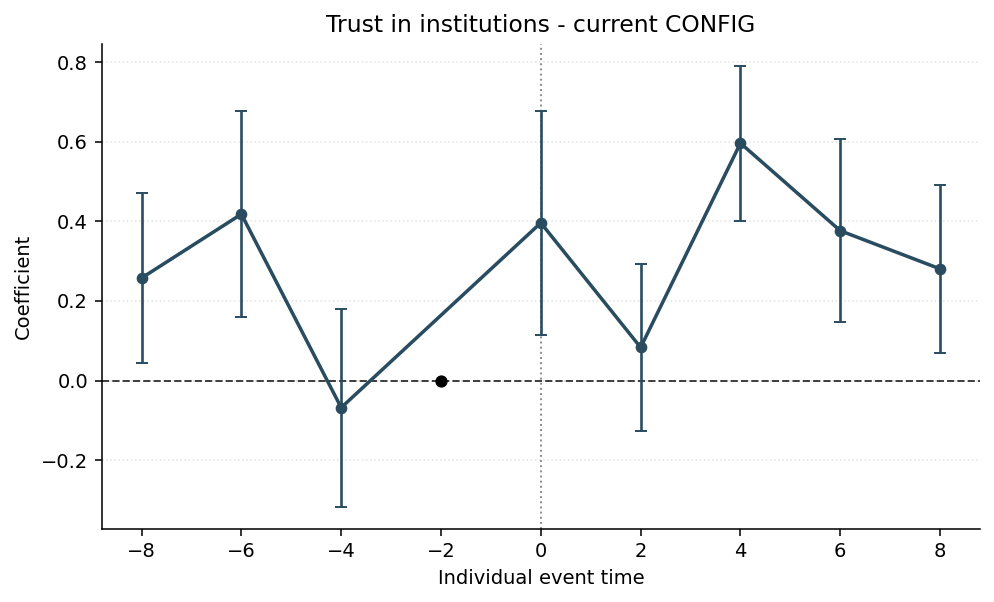

trust_index_std ~ event_m8 + event_m6 + event_m4 + event_p0 + event_p2 + event_p4 + event_p6 + event_p8 + low_ed + female + white + married + working + age + age_sq + age_cu + C(municipality_id) + C(year)
N = 2,425; clusters = 64


In [6]:
OUTCOME_TO_PLOT = "trust_index_std"  # try "democracy_index_std"


def event_terms(config: dict = CONFIG) -> list[str]:
    return [event_col(k) for k in event_grid(config) if k != config["reference_event_time"]]


def run_event_study(df: pd.DataFrame, outcome: str, config: dict = CONFIG):
    rhs_terms = event_terms(config) + config["controls"]
    result = fit_fe(df, outcome, rhs_terms, config)
    rows = []
    for k in event_grid(config):
        if k == config["reference_event_time"]:
            rows.append({"event_time": k, "term": "reference", "estimate": 0.0, "std_error": np.nan, "p_value": np.nan, "n_obs": int(result.nobs)})
            continue
        term = event_col(k)
        rows.append({
            "event_time": k,
            "term": term,
            "estimate": result.params.get(term, np.nan),
            "std_error": result.bse.get(term, np.nan),
            "p_value": result.pvalues.get(term, np.nan),
            "n_obs": int(result.nobs),
        })
    event_df = pd.DataFrame(rows)
    event_df["ci_low"] = event_df["estimate"] - 1.96 * event_df["std_error"]
    event_df["ci_high"] = event_df["estimate"] + 1.96 * event_df["std_error"]
    return event_df, result


def plot_event_study(event_df: pd.DataFrame, outcome: str, title_suffix: str = ""):
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    color = COLORS.get(outcome, "#294C60")
    ci_df = event_df.dropna(subset=["std_error"])
    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.75)
    ax.axvline(0, color="0.55", linewidth=1, linestyle=":")
    ax.errorbar(
        ci_df["event_time"],
        ci_df["estimate"],
        yerr=1.96 * ci_df["std_error"],
        fmt="o-",
        color=color,
        ecolor=color,
        elinewidth=1.35,
        capsize=3,
        markersize=5,
        linewidth=1.8,
    )
    ref = event_df[event_df["term"] == "reference"]
    if not ref.empty:
        ax.scatter(ref["event_time"], ref["estimate"], color="black", s=28, zorder=4, label="reference")
    ax.set_xticks(event_grid(CONFIG))
    ax.set_xlabel("Individual event time")
    ax.set_ylabel("Coefficient")
    ax.set_title(f"{OUTCOMES[outcome]}{title_suffix}")
    ax.grid(axis="y", linestyle=":", alpha=0.35)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    return fig, ax


event_df, event_model = run_event_study(df, OUTCOME_TO_PLOT, CONFIG)
display(event_df.round(3))
fig, ax = plot_event_study(event_df, OUTCOME_TO_PLOT, title_suffix=" - current CONFIG")
plt.show()
print(event_model.formula_text)
print(f"N = {int(event_model.nobs):,}; clusters = {event_model.model_df[CONFIG['cluster']].nunique():,}")

## 5. Compare Data-Management Scenarios

This is the most useful sandbox cell. Add, remove, or edit scenarios to see how the event-study path reacts to different sample decisions. The unbalanced-municipality scenario can take a minute because it adds many municipality fixed effects.

,rows,municipalities,municipality_year_cells,waves,min_year,max_year,under_18_rows,hybrid_rows,always_bvr_rows,low_ed_always_bvr_rows,mixed_rows,never_or_pre_bvr_rows,event_model_n,clusters
scenario,,,,,,,,,,,,,,
production_like,2425,8,64,8,2006,2020,0,0,28,2,247,2150,2425,64
allow_unbalanced_municipalities,11754,734,1316,8,2006,2020,0,0,205,25,2249,9300,11754,1316
include_ages_16_17,2471,8,64,8,2006,2020,46,0,39,6,247,2185,2471,64
drop_mixed_cohort,2178,8,62,8,2006,2020,0,0,28,2,0,2150,2178,62
treated_munis_only,814,3,24,8,2006,2020,0,0,28,2,247,539,814,24
exclude_hybrid,2425,8,64,8,2006,2020,0,0,28,2,247,2150,2425,64


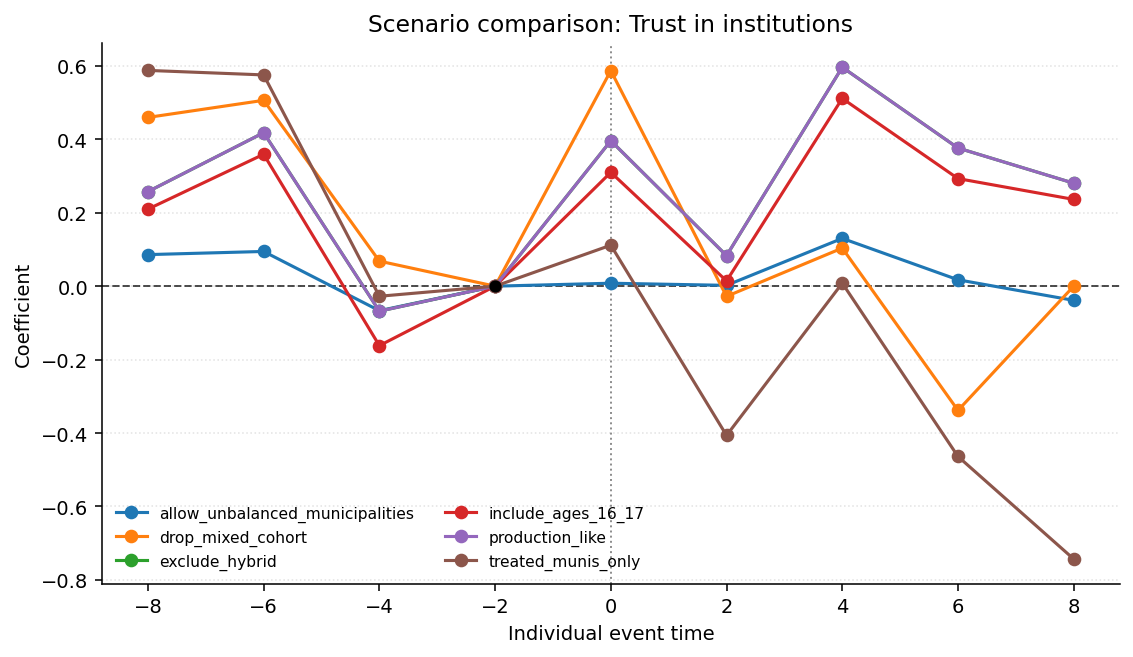

In [7]:
SCENARIOS = {
    "production_like": {},
    "allow_unbalanced_municipalities": {"require_all_wave_municipalities": False},
    "include_ages_16_17": {"drop_under_18": False},
    "drop_mixed_cohort": {"drop_mixed_cohort": True},
    "treated_munis_only": {"include_never_treated": False},
    "exclude_hybrid": {"exclude_hybrid": True},
}


def with_updates(base: dict, updates: dict) -> dict:
    out = base.copy()
    out.update(updates)
    return out


def scenario_event_results(outcome: str, scenarios: dict[str, dict], base_config: dict = CONFIG) -> tuple[pd.DataFrame, pd.DataFrame]:
    event_rows = []
    summaries = []
    for name, updates in scenarios.items():
        cfg = with_updates(base_config, updates)
        scenario_df = prepare_event_data(cfg)
        event_df, model = run_event_study(scenario_df, outcome, cfg)
        event_df["scenario"] = name
        event_df["outcome"] = outcome
        event_rows.append(event_df)
        summary = sample_summary(model.model_df)
        summary["scenario"] = name
        summary["event_model_n"] = int(model.nobs)
        summary["clusters"] = model.model_df[cfg["cluster"]].nunique()
        summaries.append(summary)
    return pd.concat(event_rows, ignore_index=True), pd.DataFrame(summaries)


scenario_events, scenario_summary = scenario_event_results(OUTCOME_TO_PLOT, SCENARIOS, CONFIG)
display(scenario_summary.set_index("scenario"))

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
ax.axvline(0, color="0.55", linewidth=1, linestyle=":")
for name, sdf in scenario_events.sort_values(["scenario", "event_time"]).groupby("scenario"):
    ax.plot(sdf["event_time"], sdf["estimate"], marker="o", linewidth=1.6, label=name)
ax.scatter([CONFIG["reference_event_time"]], [0], color="black", s=28, zorder=5)
ax.set_xticks(event_grid(CONFIG))
ax.set_xlabel("Individual event time")
ax.set_ylabel("Coefficient")
ax.set_title(f"Scenario comparison: {OUTCOMES[OUTCOME_TO_PLOT]}")
ax.grid(axis="y", linestyle=":", alpha=0.35)
ax.legend(frameon=False, fontsize=8, ncol=2)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## 6. Save an Experimental Figure

This cell is off by default. Turn it on when you have a specification you want to keep. Experimental outputs go to `resources/lapop/figures/playground/` so they do not overwrite the paper figures.

In [ ]:
SAVE_CURRENT_FIGURE = False
SAVE_SCENARIO_COMPARISON = False

PLAYGROUND_DIR = ROOT / "resources" / "lapop" / "figures" / "playground"
PLAYGROUND_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_CURRENT_FIGURE:
    event_df, _ = run_event_study(df, OUTCOME_TO_PLOT, CONFIG)
    fig, ax = plot_event_study(event_df, OUTCOME_TO_PLOT, title_suffix=" - playground")
    out = PLAYGROUND_DIR / f"{OUTCOME_TO_PLOT}_event_study_current_config.pdf"
    fig.savefig(out, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved {out.relative_to(ROOT)}")

if SAVE_SCENARIO_COMPARISON:
    out = PLAYGROUND_DIR / f"{OUTCOME_TO_PLOT}_scenario_comparison.pdf"
    fig.savefig(out, bbox_inches="tight")
    print(f"Saved {out.relative_to(ROOT)}")

## Notes While Experimenting

- If `require_all_wave_municipalities=True`, the sample is deliberately small. That is useful for within-wave comparability but very costly for support.
- If `include_never_treated=True`, never-treated municipalities help identify year fixed effects and serve as controls, but their event-time dummies are all zero.
- If `drop_mixed_cohort=True`, the always-BVR contrast becomes cleaner but the sample gets even thinner.
- If `drop_under_18=False`, the proxy uses age-18 eligibility even for 16- and 17-year-old respondents. That can be useful as a sensitivity check, but it is not the production choice.
- The notebook uses `statsmodels` with explicit fixed-effect dummies. It is convenient for exploration; the production artifacts should still be regenerated with the script when you settle on a specification.